# Khipus.ai — Estadística Aplicada con Python
## Módulo 2 · Clase 3 — Repaso relámpago de la Clase 2

**Docente:** Walter J. Méndez · UTEPSA / Khipus.ai

⏱️ *15 minutos, antes de entrar al tema de hoy.*

---

👨‍🏫 **Por qué empezamos repasando.**

Hoy vamos a usar, sin avisar, tres cosas del sábado pasado: el **p-valor**, la **hipótesis nula**
y la idea de que **una muestra no es la población**. Si alguna de las tres quedó floja, la clase
de hoy se te va a hacer cuesta arriba.

Así que las recuperamos en quince minutos, sobre **el mismo archivo** — y de paso te dejo montada
la pregunta de hoy.

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats                          # las pruebas del sábado pasado

sns.set_style("whitegrid")

_LOCAL = "../datos/data_dev.csv"
_URL = ("https://raw.githubusercontent.com/Khipus-ai/Applied_Statistics_Python/"
        "main/3%20Inferential%20Statistics/data_dev.csv")

df = pd.read_csv(_LOCAL if os.path.exists(_LOCAL) else _URL)

print(f"Encuestas: {df.shape[0]}   —   el mismo archivo del sábado pasado")

Encuestas: 1183   —   el mismo archivo del sábado pasado


## 1 · La pregunta que nos hicimos

Comparamos el sueldo de dos grupos de la encuesta:

- los que **ya usan** herramientas de IA en su trabajo,
- los que **planean usarlas**.

La pregunta era: *¿los que ya usan IA ganan más?*

In [3]:
usando = df.loc[df["plans_to_use_ai"] == "Using", "converted_comp_yearly"]
planea = df.loc[df["plans_to_use_ai"] == "Plan to use", "converted_comp_yearly"]

print(f"Ya usan IA      (n={len(usando)}):  media = ${usando.mean():,.0f}")
print(f"Planean usarla  (n={len(planea)}):  media = ${planea.mean():,.0f}")
print()
print(f"Diferencia observada: ${usando.mean() - planea.mean():,.0f} a favor de los que ya usan IA")

Ya usan IA      (n=789):  media = $92,088
Planean usarla  (n=394):  media = $87,873

Diferencia observada: $4,215 a favor de los que ya usan IA


🤔 **Antes de seguir, acordate de lo que respondiste el sábado.**

Cuatro mil doscientos dólares de diferencia, a favor de los que ya usan IA. Suena a hallazgo:
"usar IA te hace ganar más".

**¿Esa diferencia es real, o es casualidad de a quiénes les tocó responder la encuesta?**

Escribí **REAL** o **CASUALIDAD** en el chat.

In [4]:
t, p_valor = stats.ttest_ind(usando, planea, equal_var=False)

print(f"Estadístico t = {t:.3f}")
print(f"p-valor       = {p_valor:.4f}")

Estadístico t = 0.929
p-valor       = 0.3529


## 2 · La respuesta, y el vocabulario que hay que tener fresco

El p-valor dio **0,3529**.

👨‍🏫 **Cómo se lee.** El p-valor responde a esta pregunta:

> *Si en realidad **no hubiera ninguna diferencia** entre los dos grupos, ¿qué tan seguido vería
> yo una diferencia tan grande como la que vi, solo por azar?*

Respuesta: **el 35% de las veces**. Una de cada tres. Eso pasa todo el tiempo por pura casualidad.

Como 0,3529 es **mayor** que nuestro umbral α = 0,05, **no rechazamos la hipótesis nula**.

| Término | Qué era |
|---|---|
| **H₀ (hipótesis nula)** | "no hay diferencia entre los grupos" — lo que se pone a prueba |
| **H₁ (alternativa)** | "sí hay diferencia" |
| **α (alfa)** | el umbral que fijamos antes de mirar: 0,05 |
| **p-valor** | qué tan compatible es lo que vi con que H₀ sea cierta |
| **No rechazamos H₀** | *no encontramos evidencia suficiente* — **no** es lo mismo que "probamos que son iguales" |

⚠️ **La trampa del sábado pasado, otra vez:** "no rechazamos H₀" **no** significa "demostramos que
ganan lo mismo". Significa que con estos datos no alcanza para afirmar lo contrario. Ausencia de
evidencia no es evidencia de ausencia.

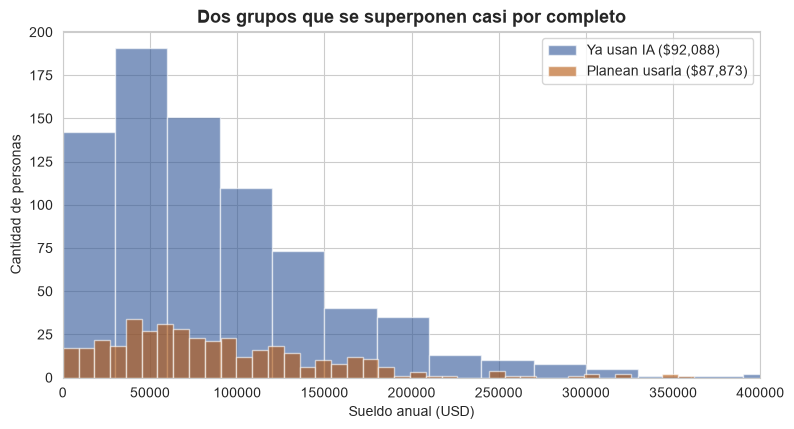

In [5]:
plt.figure(figsize=(9, 4.5))
plt.hist(usando, bins=40, alpha=0.6, label=f"Ya usan IA (${usando.mean():,.0f})", color="#2E5496")
plt.hist(planea, bins=40, alpha=0.6, label=f"Planean usarla (${planea.mean():,.0f})", color="#B45309")

plt.title("Dos grupos que se superponen casi por completo", fontsize=13, fontweight="bold")
plt.xlabel("Sueldo anual (USD)")
plt.ylabel("Cantidad de personas")
plt.xlim(0, 400_000)
plt.legend()
plt.show()

💡 **Mirando el gráfico se entiende el p-valor sin fórmulas:** las dos distribuciones están una
encima de la otra. Los $4.215 de diferencia entre las medias son una nadita al lado de lo mucho
que varían los sueldos dentro de cada grupo.

## 3 · Lo que dominás de la Clase 2

| Concepto | En una línea |
|---|---|
| Muestra vs. población | La muestra es lo que medís; la población, lo que querés conocer |
| Teorema Central del Límite | Promediá muchas muestras y la distribución de esos promedios se vuelve normal |
| Intervalo de confianza | Un rango honesto en vez de un número solo |
| Hipótesis nula (H₀) | El "no pasa nada" que ponés a prueba |
| p-valor | Qué tan raro sería lo que vi si H₀ fuera cierta |
| α = 0,05 | El umbral, fijado **antes** de mirar los datos |
| t-test | La prueba para comparar las medias de dos grupos |

## 4 · El puente hacia hoy

El sábado pasado le hiciste una pregunta a una **diferencia entre dos grupos**:

> *"¿Esta diferencia es real, o tuve suerte?"*

Y la respuesta fue **incómoda**: parecía haber algo, y no había nada (p = 0,35).

---

Hoy vas a hacerle **exactamente la misma pregunta** a otra cosa: a la **pendiente de una recta**.

> ## ¿Cuánto va a ganar un programador con 5 años de experiencia?

Y la respuesta va a ser incómoda **en la dirección contraria**: esta vez el p-valor va a ser
ridículamente chico —vas a ver un número con 23 ceros— y aun así el resultado no te va a servir
para casi nada.

💡 **Dos sábados, dos formas distintas de que la intuición te falle.** Entender las dos es la
diferencia entre correr funciones y hacer estadística.

**Abrí el notebook de hoy.** 👉 `03a_Metodos_Estadisticos_Avanzados_Practica_Guiada_Mini.ipynb`